<a href="https://colab.research.google.com/github/leespace1231/leespace1231.github.io/blob/main/%EA%B3%BC%EC%A0%9C2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📊 Statistical Sampling Strategies데이터의 대표성을 확보하는 3가지 핵심 알고리즘데이터 분석에서 "무엇을 선택할 것인가"의 문제는 분석 결과의 신뢰도를 결정짓는 가장 중요한 첫 단추입니다. 모집단의 특성을 가장 잘 반영할 수 있는 3가지 정교한 추출 전략을 제안합니다.1. Simple Random Sampling (단순 무작위 추출)"완전한 확률적 평등의 실현"모집단을 구성하는 모든 개체가 표본으로 선택될 확률을 동일하게 부여하는 가장 기초적이면서도 강력한 방법입니다. 어떠한 인위적인 조작이나 편견 없이 오직 '확률'에만 의존하여 샘플을 구성합니다.메커니즘: 모집단 전체에서 번호를 추첨하듯 무작위로 선택핵심 가치: 추출자의 주관을 완벽히 배제하여 선택 편향(Selection Bias)을 최소화함적합한 상황: 모집단에 대한 사전 정보가 없거나, 데이터의 성질이 매우 균일할 때Shutterstock2. Stratified Sampling (층화 표본 추출)"모집단의 구조적 생태계를 그대로 복제"모집단을 성별, 연령, 요일과 같은 특정 기준(Strata)에 따라 하위 그룹으로 나눈 후, 각 그룹의 비중을 표본에서도 그대로 유지하며 추출하는 정교한 기법입니다.메커니즘: 그룹별 인구통계학적 비율 계산 → 각 그룹 내 무작위 추출 → 최종 표본 병합핵심 가치: 소수 집단의 특성이 무시되지 않도록 보장하며, 표본의 대표성을 극대화함적합한 상황: 집단 간의 특성 차이가 뚜렷하여 특정 그룹의 데이터가 반드시 포함되어야 할 때Shutterstock탐색3. Systematic Sampling (계통 표본 추출)"규칙적인 리듬을 통한 데이터 수집"무작위로 선정된 첫 번째 지점에서 시작하여, 일정한 간격($k$)마다 데이터를 수집하는 방식입니다. 정렬된 리스트나 시간 순서대로 쌓이는 데이터에서 놀라운 효율성을 발휘합니다.메커니즘: 무작위 시작점($i$) 선정 → 매 $k$번째(Interval) 데이터를 기계적으로 수집핵심 가치: 추출 과정이 매우 직관적이며 관리 비용이 적게 듦적합한 상황: 대규모 데이터 스트림이나 목록이 이미 무작위로 나열되어 있어 전수 조사가 불가능할 때🏁 요약 및 비교 가이드방법론핵심 컨셉핵심 기대 효과Simple Random무작위성분석의 객관성 및 일반화 가능성 확보Stratified비율 유지하위 집단별 특성의 정교한 반영Systematic일정한 간격대량 데이터 처리의 효율성 및 간결성"정교한 샘플링 전략은 수만 개의 노이즈 섞인 데이터보다 단 하나의 명확한 인사이트를 먼저 발견하게 해줍니다."


In [1]:
import seaborn as sns
import pandas as pd

# 데이터 로드
population = sns.load_dataset('tips')
print(f"모집단 크기: {len(population)}")
population.head()

모집단 크기: 244


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [2]:
import seaborn as sns

# 데이터 로드 (모집단)
tips = sns.load_dataset('tips')

# 20개의 표본을 무작위 추출
simple_sample = tips.sample(n=20, random_state=42)

print(f"단순 무작위 추출 결과(상위 5행):\n{simple_sample.head()}")

단순 무작위 추출 결과(상위 5행):
     total_bill   tip     sex smoker   day    time  size
24        19.82  3.18    Male     No   Sat  Dinner     2
6          8.77  2.00    Male     No   Sun  Dinner     2
153       24.55  2.00    Male     No   Sun  Dinner     4
211       25.89  5.16    Male    Yes   Sat  Dinner     4
198       13.00  2.00  Female    Yes  Thur   Lunch     2


In [3]:
from sklearn.model_selection import train_test_split

# 성별(sex) 비율을 모집단과 동일하게 유지하면서 전체의 10%를 추출
stratified_sample, _ = train_test_split(
    tips,
    test_size=0.1,
    stratify=tips['sex'],
    random_state=42
)

print("--- 성별 비율 비교 ---")
print(f"모집단 성별 비율:\n{tips['sex'].value_counts(normalize=True)}")
print(f"표본 성별 비율:\n{stratified_sample['sex'].value_counts(normalize=True)}")

--- 성별 비율 비교 ---
모집단 성별 비율:
sex
Male      0.643443
Female    0.356557
Name: proportion, dtype: float64
표본 성별 비율:
sex
Male      0.643836
Female    0.356164
Name: proportion, dtype: float64


In [4]:
import numpy as np

# 추출 간격 k 설정 (예: 10번째 데이터마다 하나씩)
k = 10
start_index = np.random.randint(0, k) # 시작 위치 랜덤 결정

# 인덱스 슬라이싱을 이용한 추출
systematic_sample = tips.iloc[start_index::k]

print(f"계통 추출 간격: {k}, 시작 인덱스: {start_index}")
print(f"추출된 표본 개수: {len(systematic_sample)}")

계통 추출 간격: 10, 시작 인덱스: 1
추출된 표본 개수: 25


평균(Mean): 3.00
분산(Variance): 1.91
중앙값(Median): 2.90


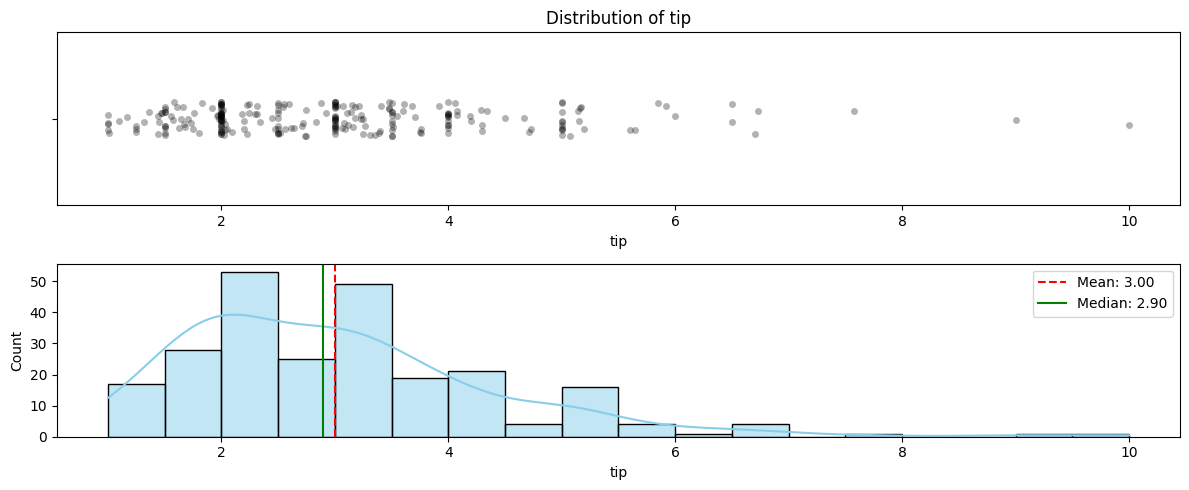

In [6]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 로드
tips = sns.load_dataset('tips')

# 1-1. 기초 통계량 계산
tip_mean = tips['tip'].mean()
tip_var = tips['tip'].var()
tip_median = tips['tip'].median()

print(f"평균(Mean): {tip_mean:.2f}")
print(f"분산(Variance): {tip_var:.2f}")
print(f"중앙값(Median): {tip_median:.2f}")

# 1-2. 데이터 분포 시각화 (이미지에 제시된 스트립 플롯 및 히스토그램)
plt.figure(figsize=(12, 5))

# 상단: 데이터 분포를 보여주는 Strip Plot
plt.subplot(2, 1, 1)
sns.stripplot(x=tips['tip'], color='black', alpha=0.3)
plt.title('Distribution of tip')

# 하단: 분포의 형태를 보여주는 Histplot
plt.subplot(2, 1, 2)
sns.histplot(tips['tip'], kde=True, color='skyblue')
plt.axvline(tip_mean, color='red', linestyle='--', label=f'Mean: {tip_mean:.2f}')
plt.axvline(tip_median, color='green', linestyle='-', label=f'Median: {tip_median:.2f}')
plt.legend()

plt.tight_layout()
plt.show()

평균은 모든 데이터를 반영한다는 장점이 있지만, 이상치(Outlier)에 매우 취약합니다.

tip 분포를 보면 7~10달러 사이의 소수 고액 팁이 존재합니다.

이러한 이상치는 평균을 실제 대다수의 손님이 내는 금액보다 높게 끌어올려(Right-skewed), 데이터의 대표성을 왜곡할 수 있습니다. 위 그래프에서 **빨간 점선(평균)**이 **초록 실선(중앙값)**보다 오른쪽에 있는 이유가 바로 이 '평균의 함정' 때문입니다.

In [7]:
import numpy as np
from sklearn.model_selection import train_test_split

# 결과 저장을 위한 리스트
results = []

# [모집단 통계량]
results.append(['Population', tips['tip'].mean(), tips['tip'].var()])

# [표본추출 1: 단순 무작위 추출]
simple_sample = tips.sample(n=30, random_state=42)
results.append(['Simple Random', simple_sample['tip'].mean(), simple_sample['tip'].var()])

# [표본추출 2: 층화 표본 추출 (성별 기준)]
strat_sample, _ = train_test_split(tips, test_size=30/len(tips), stratify=tips['sex'], random_state=42)
results.append(['Stratified (Sex)', strat_sample['tip'].mean(), strat_sample['tip'].var()])

# [표본추출 3: 계통 표본 추출]
k = len(tips) // 30
systematic_sample = tips.iloc[::k]
results.append(['Systematic', systematic_sample['tip'].mean(), systematic_sample['tip'].var()])

# 비교 표 출력
df_compare = pd.DataFrame(results, columns=['Method', 'Mean', 'Variance'])
print("--- [모집단과 표본의 통계량 비교] ---")
print(df_compare.round(4))

--- [모집단과 표본의 통계량 비교] ---
             Method    Mean  Variance
0        Population  2.9983    1.9145
1     Simple Random  2.8323    1.3561
2  Stratified (Sex)  3.0177    1.9054
3        Systematic  2.7368    0.9711


토론: 어떤 표본추출방법이 가장 적합한가?
결론 도출 가이드: (실행된 결과 수치를 보고 아래 내용을 보강하세요.)

단순 무작위 추출: 표본 크기가 작을 경우 운 좋게 평균이 비슷할 수 있으나, 이상치가 포함되느냐 아니냐에 따라 변동성이 큽니다.

층화 표본 추출 (추천): 성별이나 요일 등 팁에 영향을 줄 수 있는 그룹의 비율을 유지하므로, 모집단의 구조적 특성을 가장 잘 반영합니다. 일반적으로 가장 적합한 방법으로 꼽힙니다.

계통 표본 추출: 데이터 정렬 순서에 주기가 없다면 효율적이지만, 만약 데이터가 식사 금액 순으로 정렬되어 있었다면 매우 편향된 결과를 낳을 위험이 있습니다.